In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Save file path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_dir = os.path.join(project_root, "data", "raw")
os.makedirs(data_dir, exist_ok=True)

In [3]:
#Load combined file
path = os.path.join(data_dir,"COMBINED_CLEANED.csv")
combined = pd.read_csv(path)

In [9]:
combined.set_index('Date', inplace=True)
combined

,Unnamed: 0,APPL,AMD,MSFT,NVDA
Date,,,,,
2020-01-02,0,72.538521,49.099998,152.791153,5.971410
2020-01-03,1,71.833282,48.599998,150.888626,5.875832
2020-01-06,2,72.405670,48.389999,151.278595,5.900473
2020-01-07,3,72.065163,48.250000,149.899307,5.971908
2020-01-08,4,73.224403,47.830002,152.286972,5.983109
...,...,...,...,...,...
2024-12-24,1253,257.286652,126.290001,436.929138,140.189468
2024-12-26,1254,258.103729,125.059998,435.715790,139.899521
2024-12-27,1255,254.685867,125.190002,428.177216,136.980164


In [ ]:
percent_change = combined.pct_change().dropna()
percent_change

,Unnamed: 0,APPL,AMD,MSFT,NVDA
Date,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN
2020-01-03,inf,-0.009722,-0.010183,-0.012452,-0.016006
2020-01-06,1.000000,0.007968,-0.004321,0.002584,0.004194
2020-01-07,0.500000,-0.004703,-0.002893,-0.009118,0.012107
2020-01-08,0.333333,0.016086,-0.008705,0.015928,0.001876
...,...,...,...,...,...
2024-12-24,0.000799,0.011478,0.013563,0.009374,0.003938
2024-12-26,0.000798,0.003176,-0.009740,-0.002777,-0.002068
2024-12-27,0.000797,-0.013242,0.001040,-0.017302,-0.020868


In [12]:
percent_change.drop(columns=['Unnamed: 0'], inplace=True)
percent_change

,APPL,AMD,MSFT,NVDA
Date,,,,
2020-01-02,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,-0.010183,-0.012452,-0.016006
2020-01-06,0.007968,-0.004321,0.002584,0.004194
2020-01-07,-0.004703,-0.002893,-0.009118,0.012107
2020-01-08,0.016086,-0.008705,0.015928,0.001876
...,...,...,...,...
2024-12-24,0.011478,0.013563,0.009374,0.003938
2024-12-26,0.003176,-0.009740,-0.002777,-0.002068
2024-12-27,-0.013242,0.001040,-0.017302,-0.020868


In [15]:
mean_returns = percent_change.mean()
TRADE_DAYS = 252
annual_mean_returns = mean_returns * TRADE_DAYS

In [16]:
covariance_matrix = percent_change.cov()
annual_covariance_matrix = covariance_matrix * TRADE_DAYS
annual_covariance_matrix

,APPL,AMD,MSFT,NVDA
APPL,0.100354,0.093347,0.072297,0.103501
AMD,0.093347,0.275202,0.096561,0.211132
MSFT,0.072297,0.096561,0.093008,0.112086
NVDA,0.103501,0.211132,0.112086,0.290293


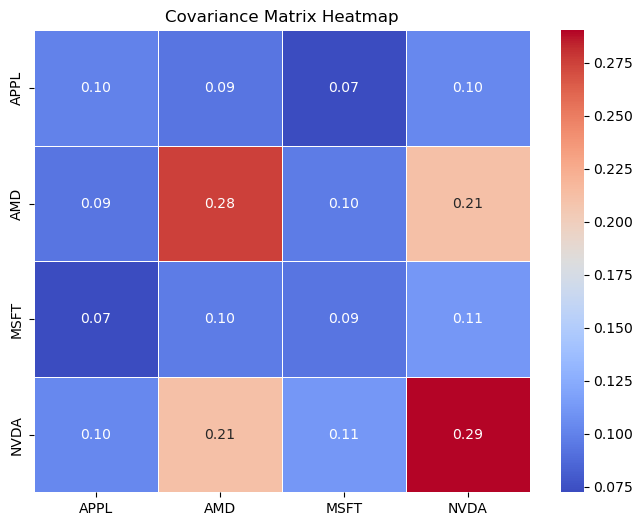

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(annual_covariance_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Covariance Matrix Heatmap')
plt.show()